# Eyeball features — the "believe one feature" check (DESIGN.md §4 step 5)

Interactive companion to `scripts/02_train_small.py`. It does **not** retrain — it loads the
already-saved `sae.pt`, so you can try a bunch of features against the same held-out positions.

The point is **discovery, not testing**: you have no hypothesis. Pick a feature, look at the
positions where it fires hardest (square marked), and read the shared chess concept off them.
If the top firings share an obvious property → you "believe" the feature is real.

> **Prereqs:** `mine_feature` + `top_activating` in `src/eval/feature_mining.py` must be
> implemented (run `pytest tests/test_feature_mining.py` until green), and you must have a
> trained `outputs/sae.pt` from running `scripts/02_train_small.py`. Until then the mining
> cells raise `NotImplementedError` — that's expected.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import yaml
from pathlib import Path

import torch

from src import hook
from src.data import positions
from src.eval import feature_mining
from src.viz.features import show_top_activations

with open(Path("../configs/default.yaml")) as f:
    cfg = yaml.safe_load(f)
cfg

/home/cowifornia/code/leela-sae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'residual_modual': 7,
 'base_model_batch': 256,
 'output_path': './outputs',
 'seed': 67,
 'sae_hidden_factor': 8,
 'top_k': 32,
 'epochs': 2,
 'lr': 0.001,
 'warmup_steps': 100,
 'aux_coef': 0.1,
 'aux_k': 1024,
 'sae_batch': 4096,
 'train_eval_freq': 10,
 'dead_window': 25,
 'eval_sample': 16}

## Load the net + the saved SAE

`module` is the residual-stream site name (string) the SAE was trained on — same index
(`cfg['residual_modual']`) as the training run, so the activations line up.

In [3]:
base_model = hook.load_model().eval()
module = hook.list_residual_modules(base_model)[cfg["residual_modual"]]

# Whole TopKSAE was saved via torch.save(sae, ...); weights_only=False to unpickle the module.
sae = torch.load(Path("../", cfg["output_path"], "sae.pt"), weights_only=False).eval()
print("residual site:", module)
print("dict size (F):", sae.encoder.out_features, "| top_k:", sae.k)

residual site: module.encoder7/ln2
dict size (F): 6144 | top_k: 32


## Reproduce the held-out eval split

Same `load_fens(limit, shuffle, seed)` + 90/10 split as `02_train_small.py`, so these are the
positions the SAE did **not** train on. 200 FENs is a fast start; bump `limit` (or also mine the
train split) if a feature's firings are too sparse to read.

In [4]:
fens = positions.load_fens(limit=20_000, shuffle=True, seed=cfg["seed"])
split = int(0.9 * len(fens))
eval_fens = fens[split:]
len(eval_fens)

2000

## Find live features (density scan)

No more guessing indices. `feature_liveness` runs the net over the eval set **once**, encodes all
F features, and returns a `(F,)` firing-density vector (fraction of tokens each feature fires on).
`density == 0` is dead.

In [5]:
density = feature_mining.feature_liveness(base_model, eval_fens, sae, module)  # (F,)

live = (density > 0).nonzero(as_tuple=True)[0]          # drop the dead features
order = live[density[live].argsort()]                   # sort live features by density (rarest first)
print(f"{len(live)}/{len(density)} features fired at least once")

/home/cowifornia/code/leela-sae/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  x = x[pos_axes_slices]


5043/6144 features fired at least once


## Show features above a density threshold

Separate knob from the scan above: pick a minimum density and list every feature at or above it,
densest first. Raise `density_threshold` to find fire-everywhere junk, lower it to surface rare
candidates.

In [6]:
density_threshold = 0.01            # fraction of tokens (%); tweak freely

above = order[density[order] >= density_threshold]      # live features >= threshold (rarest -> densest)
print(f"{len(above)} features fire on >= {density_threshold:.2%} of tokens")
for f_idx in reversed(above.tolist()):                  # densest first
    print(f"feature {f_idx:>4}: density {density[f_idx]:.4%}")

958 features fire on >= 1.00% of tokens
feature  182: density 27.0430%
feature 2453: density 23.7383%
feature 2816: density 20.6008%
feature 1783: density 16.5539%
feature 1127: density 16.1594%
feature 4514: density 15.8906%
feature 3810: density 15.3680%
feature 3197: density 15.1438%
feature 5777: density 15.0867%
feature 4106: density 13.7672%
feature 5008: density 13.0328%
feature 5099: density 11.5508%
feature 2940: density 11.5258%
feature 1314: density 11.2984%
feature 2197: density 10.7469%
feature 2296: density 10.6969%
feature 2742: density 10.5164%
feature 5293: density 10.3648%
feature 3891: density 10.0664%
feature 5995: density 9.8414%
feature 2493: density 9.7969%
feature 3188: density 9.6367%
feature 5931: density 9.6320%
feature 1021: density 9.5563%
feature 1403: density 9.1938%
feature  811: density 9.0578%
feature 3757: density 9.0313%
feature 4923: density 8.7617%
feature 2489: density 8.7203%
feature  821: density 8.6648%
feature 2026: density 8.6516%
feature  70

## Plot all feature densities

Histogram over every feature's firing density. Dead features (density 0) can't sit on a log axis,
so they're counted in the title; the log-x scale spreads the live mass that would otherwise pile
into one bin.

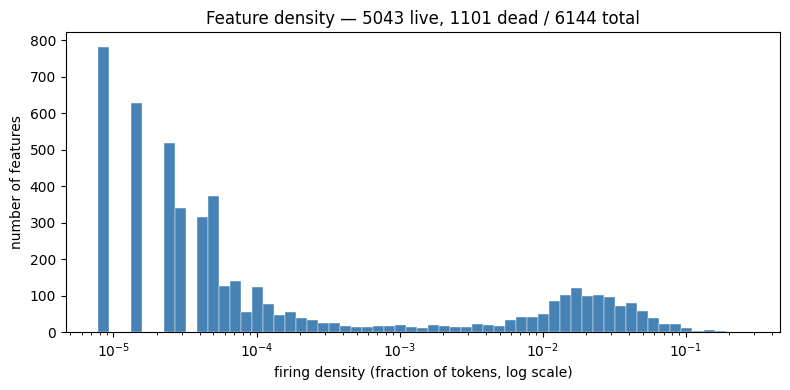

In [7]:
import matplotlib.pyplot as plt
import numpy as np

d = density.cpu().numpy()
live_d = d[d > 0]                                       # log axis can't show density == 0
n_dead = int((d == 0).sum())

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(np.log10(live_d.min()), np.log10(live_d.max()), 60)
ax.hist(live_d, bins=bins, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_xlabel("firing density (fraction of tokens, log scale)")
ax.set_ylabel("number of features")
ax.set_title(f"Feature density — {len(live_d)} live, {n_dead} dead / {len(d)} total")
plt.tight_layout()
plt.show()

## Eyeball ONE feature

Change `feature_index`, re-run. Watch the marked squares — do they share a chess property
(a passed pawn, an exposed king, an outpost)? Avoid features that never fire or fire everywhere;
the scan cell below helps you find ones worth looking at.

In [8]:
feature_index = 37

results = feature_mining.mine_feature(base_model, eval_fens, sae, module, feature_index, k=20)
show_top_activations(feature_index, results)

/home/cowifornia/code/leela-sae/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  x = x[pos_axes_slices]
